# Timeseries Forecasting for Weather Prediction — Incremental LSTM Experiments

**Author:** [Oluwadabira Omotoso](https://dabby04.com/github)   

**Description:** This notebook builds upon the official Keras example for time series forecasting using an LSTM model, introducing three incremental architectural experiments with the goal of progressively improving model performance on the Jena Climate dataset. Each experiment builds on the best configuration from the previous one. For the original baseline implementation, refer to the official Keras example: https://keras.io/examples/timeseries/timeseries_weather_forecasting/

**Note: All code before Train and Evaluate Section uses baseline setup.**

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import keras

## Climate Data Time-Series

We will be using Jena Climate dataset recorded by the
[Max Planck Institute for Biogeochemistry](https://www.bgc-jena.mpg.de/wetter/).
The dataset consists of 14 features such as temperature, pressure, humidity etc, recorded once per
10 minutes.

**Location**: Weather Station, Max Planck Institute for Biogeochemistry
in Jena, Germany

**Time-frame Considered**: Jan 10, 2009 - December 31, 2016


The table below shows the column names, their value formats, and their description.

Index| Features      |Format             |Description
-----|---------------|-------------------|-----------------------
1    |Date Time      |01.01.2009 00:10:00|Date-time reference
2    |p (mbar)       |996.52             |The pascal SI derived unit of pressure used to quantify internal pressure. Meteorological reports typically state atmospheric pressure in millibars.
3    |T (degC)       |-8.02              |Temperature in Celsius
4    |Tpot (K)       |265.4              |Temperature in Kelvin
5    |Tdew (degC)    |-8.9               |Temperature in Celsius relative to humidity. Dew Point is a measure of the absolute amount of water in the air, the DP is the temperature at which the air cannot hold all the moisture in it and water condenses.
6    |rh (%)         |93.3               |Relative Humidity is a measure of how saturated the air is with water vapor, the %RH determines the amount of water contained within collection objects.
7    |VPmax (mbar)   |3.33               |Saturation vapor pressure
8    |VPact (mbar)   |3.11               |Vapor pressure
9    |VPdef (mbar)   |0.22               |Vapor pressure deficit
10   |sh (g/kg)      |1.94               |Specific humidity
11   |H2OC (mmol/mol)|3.12               |Water vapor concentration
12   |rho (g/m ** 3) |1307.75            |Airtight
13   |wv (m/s)       |1.03               |Wind speed
14   |max. wv (m/s)  |1.75               |Maximum wind speed
15   |wd (deg)       |152.3              |Wind direction in degrees

In [2]:
from zipfile import ZipFile

uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = keras.utils.get_file(origin=uri, fname="jena_climate_2009_2016.csv.zip")
zip_file = ZipFile(zip_path)
zip_file.extractall()
csv_path = "jena_climate_2009_2016.csv"

df = pd.read_csv(csv_path)

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Raw Data Visualization

To give us a sense of the data we are working with, each feature has been plotted below.
This shows the distinct pattern of each feature over the time period from 2009 to 2016.
It also shows where anomalies are present, which will be addressed during normalization.

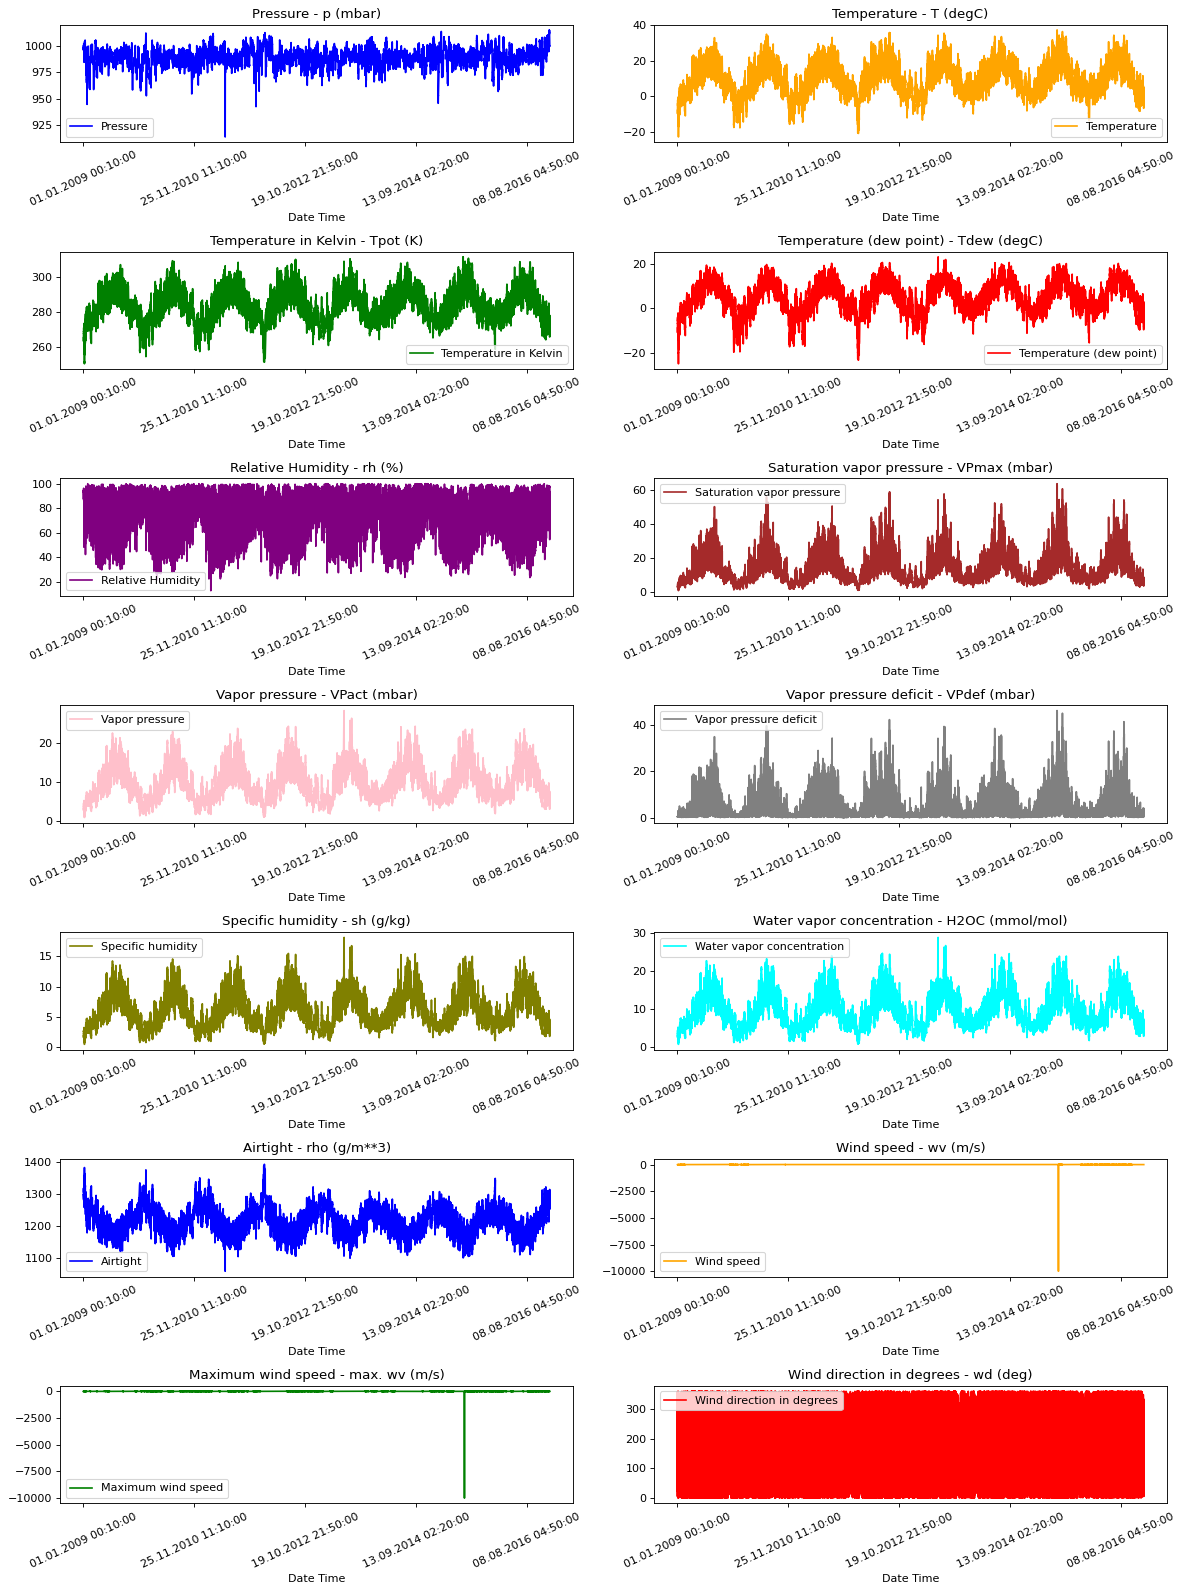

In [3]:
titles = [
    "Pressure",
    "Temperature",
    "Temperature in Kelvin",
    "Temperature (dew point)",
    "Relative Humidity",
    "Saturation vapor pressure",
    "Vapor pressure",
    "Vapor pressure deficit",
    "Specific humidity",
    "Water vapor concentration",
    "Airtight",
    "Wind speed",
    "Maximum wind speed",
    "Wind direction in degrees",
]

feature_keys = [
    "p (mbar)",
    "T (degC)",
    "Tpot (K)",
    "Tdew (degC)",
    "rh (%)",
    "VPmax (mbar)",
    "VPact (mbar)",
    "VPdef (mbar)",
    "sh (g/kg)",
    "H2OC (mmol/mol)",
    "rho (g/m**3)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)",
]

colors = [
    "blue",
    "orange",
    "green",
    "red",
    "purple",
    "brown",
    "pink",
    "gray",
    "olive",
    "cyan",
]

date_time_key = "Date Time"


def show_raw_visualization(data):
    time_data = data[date_time_key]
    fig, axes = plt.subplots(
        nrows=7, ncols=2, figsize=(15, 20), dpi=80, facecolor="w", edgecolor="k"
    )
    for i in range(len(feature_keys)):
        key = feature_keys[i]
        c = colors[i % (len(colors))]
        t_data = data[key]
        t_data.index = time_data
        t_data.head()
        ax = t_data.plot(
            ax=axes[i // 2, i % 2],
            color=c,
            title="{} - {}".format(titles[i], key),
            rot=25,
        )
        ax.legend([titles[i]])
    plt.tight_layout()


show_raw_visualization(df)

## Data Preprocessing

Here we are picking ~300,000 data points for training. Observation is recorded every
10 mins, that means 6 times per hour. We will resample one point per hour since no
drastic change is expected within 60 minutes. We do this via the `sampling_rate`
argument in `timeseries_dataset_from_array` utility.

We are tracking data from past 720 timestamps (720/6=120 hours). This data will be
used to predict the temperature after 72 timestamps (72/6=12 hours).

Since every feature has values with
varying ranges, we do normalization to confine feature values to a range of `[0, 1]` before
training a neural network.
We do this by subtracting the mean and dividing by the standard deviation of each feature.

71.5 % of the data will be used to train the model, i.e. 300,693 rows. `split_fraction` can
be changed to alter this percentage.

The model is shown data for first 5 days i.e. 720 observations, that are sampled every
hour. The temperature after 72 (12 hours * 6 observation per hour) observation will be
used as a label.

In [4]:
split_fraction = 0.715
train_split = int(split_fraction * int(df.shape[0]))
step = 6

past = 720
future = 72
learning_rate = 0.001
batch_size = 256
epochs = 10


def normalize(data, train_split):
    data_mean = data[:train_split].mean(axis=0)
    data_std = data[:train_split].std(axis=0)
    return (data - data_mean) / data_std

We can see from the correlation heatmap, few parameters like Relative Humidity and
Specific Humidity are redundant. Hence we will be using select features, not all.

In [5]:
print(
    "The selected parameters are:",
    ", ".join([titles[i] for i in [0, 1, 5, 7, 8, 10, 11]]),
)
selected_features = [feature_keys[i] for i in [0, 1, 5, 7, 8, 10, 11]]
features = df[selected_features]
features.index = df[date_time_key]
features.head()

features = normalize(features.values, train_split)
features = pd.DataFrame(features)
features.head()

train_data = features.loc[0 : train_split - 1]
val_data = features.loc[train_split:]

The selected parameters are: Pressure, Temperature, Saturation vapor pressure, Vapor pressure deficit, Specific humidity, Airtight, Wind speed


# Training dataset

The training dataset labels starts from the 792nd observation (720 + 72).

In [6]:
start = past + future
end = start + train_split

x_train = train_data[[i for i in range(7)]].values
y_train = features.iloc[start:end][[1]]

sequence_length = int(past / step)

The `timeseries_dataset_from_array` function takes in a sequence of data-points gathered at
equal intervals, along with time series parameters such as length of the
sequences/windows, spacing between two sequence/windows, etc., to produce batches of
sub-timeseries inputs and targets sampled from the main timeseries.

In [7]:
dataset_train = keras.preprocessing.timeseries_dataset_from_array(
    x_train,
    y_train,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

## Validation dataset

The validation dataset must not contain the last 792 rows as we won't have label data for
those records, hence 792 must be subtracted from the end of the data.

The validation label dataset must start from 792 after train_split, hence we must add
past + future (792) to label_start.

In [8]:
x_end = len(val_data) - past - future

label_start = train_split + past + future

x_val = val_data.iloc[:x_end][[i for i in range(7)]].values
y_val = features.iloc[label_start:][[1]]

dataset_val = keras.preprocessing.timeseries_dataset_from_array(
    x_val,
    y_val,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)


for batch in dataset_train.take(1):
    inputs, targets = batch

print("Input shape:", inputs.numpy().shape)
print("Target shape:", targets.numpy().shape)

Input shape: (256, 120, 7)
Target shape: (256, 1)


## Train and Evaluate


In [9]:
def visualize_loss(history, title):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(len(loss))
    plt.figure()
    plt.plot(epochs, loss, "b", label="Training loss")
    plt.plot(epochs, val_loss, "r", label="Validation loss")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.show()


---
## Experiment 1: Double LSTM Hidden Units

| Parameter | Baseline | This Experiment |
|-----------|----------|-----------------|
| LSTM units | 32 | 64 |

**Why:** The baseline LSTM has only 32 hidden units, which limits the amount of temporal information it can store. Doubling the units to 64 increases the model's capacity to learn more complex patterns from the weather time series data. This is our first step toward a more powerful model.


In [10]:
# ── Experiment 1: LSTM units=64 ──
past = 720
sequence_length = int(past / step)

# Rebuild datasets with updated sequence length
start = past + future
end = start + train_split
x_train = train_data[[i for i in range(7)]].values
y_train = features.iloc[start:end][[1]]

dataset_train = keras.preprocessing.timeseries_dataset_from_array(
    x_train,
    y_train,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

x_end = len(val_data) - past - future
label_start = train_split + past + future
x_val = val_data.iloc[:x_end][[i for i in range(7)]].values
y_val = features.iloc[label_start:][[1]]

dataset_val = keras.preprocessing.timeseries_dataset_from_array(
    x_val,
    y_val,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

for batch in dataset_train.take(1):
    inputs_batch, targets = batch

# Build model
inputs = keras.layers.Input(shape=(inputs_batch.shape[1], inputs_batch.shape[2]))
lstm_out = keras.layers.LSTM(units=64)(inputs)
outputs = keras.layers.Dense(1)(lstm_out)
model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse")
model.summary()

# Train
path_checkpoint = "model_checkpoint_exp1.weights.h5"
es_callback = keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=5)
modelckpt_callback = keras.callbacks.ModelCheckpoint(
    monitor="val_loss",
    filepath=path_checkpoint,
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

history_exp1 = model.fit(
    dataset_train,
    epochs=epochs,
    validation_data=dataset_val,
    callbacks=[es_callback, modelckpt_callback],
)

print('\n=== Experiment 1 Result (LSTM units=64) ===')
min_val_loss = min(history_exp1.history['val_loss'])
print(f'Experiment 1 Best Val Loss: {min_val_loss:.4f}')


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,497 (72.25 KB)

 Trainable params: 18,497 (72.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.3062
Epoch 1: val_loss improved from None to 0.14728, saving model to model_checkpoint_exp1.weights.h5

Epoch 1: finished saving model to model_checkpoint_exp1.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 68s 55ms/step - loss: 0.1712 - val_loss: 0.1473
Epoch 2/10
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.1415
Epoch 2: val_loss did not improve from 0.14728
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 61s 52ms/step - loss: 0.1237 - val_loss: 0.1539
Epoch 3/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1241
Epoch 3: val_loss did not improve from 0.14728
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 63s 53ms/step - loss: 0.1165 - val_loss: 0.1635
Epoch 4/10
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1185
Epoch 4: val_loss did not improve from 0.14728
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 62s 53ms/step - loss: 0.1112 - val_loss: 0.1729
Epoch 5/10
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1209
Epoch 5: val_loss did not i

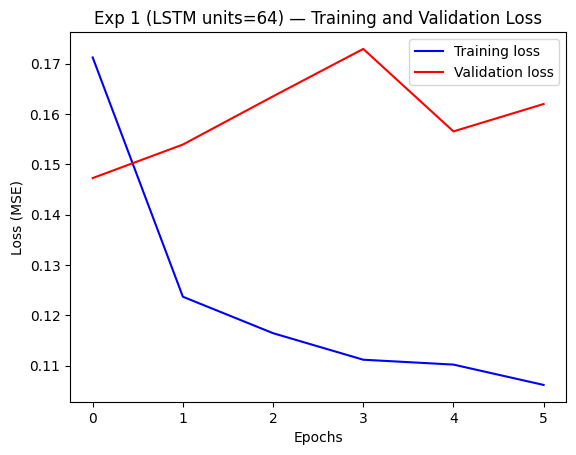

In [11]:
visualize_loss(history_exp1, "Exp 1 (LSTM units=64) — Training and Validation Loss")


---
## Experiment 2: Stack a Second LSTM Layer

| Parameter | Baseline | Experiment 1    |This Experiment |
|-----------|----------|-----------------|---------------|
| LSTM units | 32 | 64 |64|
| LSTM layers | 1 | 1  | 2 |

**Why:** Experiment 1 achieved a best val_loss of 0.1473 at Epoch 1, but the validation loss increased every epoch after that, indicating the model was overfitting; it learned the training data well but failed to generalize. Building on Experiment 1's increased units, we now add a second LSTM layer to address this. Stacking LSTM layers allows the model to learn hierarchical temporal representations. The first layer learns low-level patterns and the second layer learns higher-level dependencies across those patterns, which can improve generalization on unseen data.


In [12]:
# ── Experiment 2: 2 stacked LSTMs, units=64 ──
past = 720
sequence_length = int(past / step)

# Rebuild datasets with updated sequence length
start = past + future
end = start + train_split
x_train = train_data[[i for i in range(7)]].values
y_train = features.iloc[start:end][[1]]

dataset_train = keras.preprocessing.timeseries_dataset_from_array(
    x_train,
    y_train,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

x_end = len(val_data) - past - future
label_start = train_split + past + future
x_val = val_data.iloc[:x_end][[i for i in range(7)]].values
y_val = features.iloc[label_start:][[1]]

dataset_val = keras.preprocessing.timeseries_dataset_from_array(
    x_val,
    y_val,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

for batch in dataset_train.take(1):
    inputs_batch, targets = batch

# Build model
inputs = keras.layers.Input(shape=(inputs_batch.shape[1], inputs_batch.shape[2]))
lstm_out = keras.layers.LSTM(units=64, return_sequences=True)(inputs)
lstm_out = keras.layers.LSTM(units=64)(lstm_out)
outputs = keras.layers.Dense(1)(lstm_out)
model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse")
model.summary()

# Train
path_checkpoint = "model_checkpoint_exp2.weights.h5"
es_callback = keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=5)
modelckpt_callback = keras.callbacks.ModelCheckpoint(
    monitor="val_loss",
    filepath=path_checkpoint,
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

history_exp2 = model.fit(
    dataset_train,
    epochs=epochs,
    validation_data=dataset_val,
    callbacks=[es_callback, modelckpt_callback],
)

print('\n=== Experiment 2 Result (2 stacked LSTMs, units=64) ===')
min_val_loss = min(history_exp2.history['val_loss'])
print(f'Experiment 2 Best Val Loss: {min_val_loss:.4f}')


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 120, 64)        │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,521 (201.25 KB)

 Trainable params: 51,521 (201.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.2772
Epoch 1: val_loss improved from None to 0.16539, saving model to model_checkpoint_exp2.weights.h5

Epoch 1: finished saving model to model_checkpoint_exp2.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 69s 57ms/step - loss: 0.1759 - val_loss: 0.1654
Epoch 2/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1458
Epoch 2: val_loss did not improve from 0.16539
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 68s 58ms/step - loss: 0.1284 - val_loss: 0.1727
Epoch 3/10
1171/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.1338
Epoch 3: val_loss improved from 0.16539 to 0.15939, saving model to model_checkpoint_exp2.weights.h5

Epoch 3: finished saving model to model_checkpoint_exp2.weights.h5
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 68s 58ms/step - loss: 0.1212 - val_loss: 0.1594
Epoch 4/10
1172/1172 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1269
Epoch 4: val_loss improved from 0.15939 to 0.15844, saving model to model_checkpoint_exp2.weights.h5


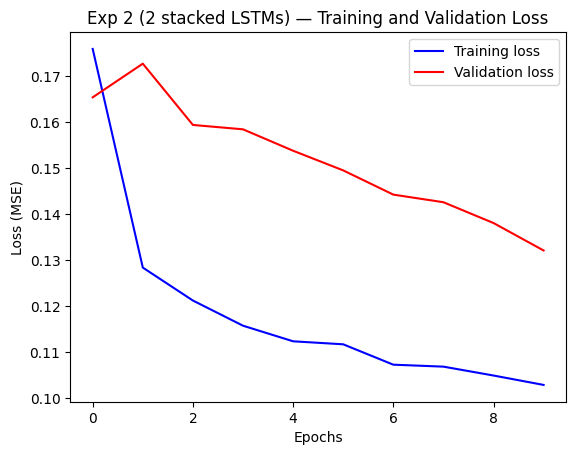

In [13]:
visualize_loss(history_exp2, "Exp 2 (2 stacked LSTMs) — Training and Validation Loss")


---
## Experiment 3: Reduce Input Sequence Length

| Parameter | Baseline | Experiment 1    |Experiment 2 | This Experiment |
|-----------|----------|-----------------|---------------|---------------|
| LSTM units | 32 | 64 |64|64|
| LSTM layers | 1 | 1  | 2 |2|
| past | 720 | 720|720|360 |

**Why:** Experiment 2 demonstrated that the stacked LSTM architecture significantly improved generalization, achieving a best val_loss of 0.1321 compared to 0.1473 in Experiment 1. Building on this stronger architecture, we now reduce the input sequence length from 720 observations (5 days) to 360 observations (2.5 days). Weather patterns often contain short-term dependencies that a capable model should be able to exploit without needing a full 5 days of history. This tests whether the two-layer model can maintain accurate predictions with less historical context, while also reducing computational cost per training step.


In [14]:
# ── Experiment 3: 2 stacked LSTMs, past=360 ──
past = 360
sequence_length = int(past / step)

# Rebuild datasets with updated sequence length
start = past + future
end = start + train_split
x_train = train_data[[i for i in range(7)]].values
y_train = features.iloc[start:end][[1]]

dataset_train = keras.preprocessing.timeseries_dataset_from_array(
    x_train,
    y_train,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

x_end = len(val_data) - past - future
label_start = train_split + past + future
x_val = val_data.iloc[:x_end][[i for i in range(7)]].values
y_val = features.iloc[label_start:][[1]]

dataset_val = keras.preprocessing.timeseries_dataset_from_array(
    x_val,
    y_val,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

for batch in dataset_train.take(1):
    inputs_batch, targets = batch

# Build model
inputs = keras.layers.Input(shape=(inputs_batch.shape[1], inputs_batch.shape[2]))
lstm_out = keras.layers.LSTM(units=64, return_sequences=True)(inputs)
lstm_out = keras.layers.LSTM(units=64)(lstm_out)
outputs = keras.layers.Dense(1)(lstm_out)
model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse")
model.summary()

# Train
path_checkpoint = "model_checkpoint_exp3.weights.h5"
es_callback = keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=5)
modelckpt_callback = keras.callbacks.ModelCheckpoint(
    monitor="val_loss",
    filepath=path_checkpoint,
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

history_exp3 = model.fit(
    dataset_train,
    epochs=epochs,
    validation_data=dataset_val,
    callbacks=[es_callback, modelckpt_callback],
)

print('\n=== Experiment 3 Result (2 stacked LSTMs, past=360) ===')
min_val_loss = min(history_exp3.history['val_loss'])
print(f'Experiment 3 Best Val Loss: {min_val_loss:.4f}')


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 60, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,521 (201.25 KB)

 Trainable params: 51,521 (201.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1173/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.2439
Epoch 1: val_loss improved from None to 0.15739, saving model to model_checkpoint_exp3.weights.h5

Epoch 1: finished saving model to model_checkpoint_exp3.weights.h5
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 65s 53ms/step - loss: 0.1690 - val_loss: 0.1574
Epoch 2/10
1173/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.1530
Epoch 2: val_loss improved from 0.15739 to 0.14778, saving model to model_checkpoint_exp3.weights.h5

Epoch 2: finished saving model to model_checkpoint_exp3.weights.h5
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 63s 54ms/step - loss: 0.1333 - val_loss: 0.1478
Epoch 3/10
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.1372
Epoch 3: val_loss improved from 0.14778 to 0.14685, saving model to model_checkpoint_exp3.weights.h5

Epoch 3: finished saving model to model_checkpoint_exp3.weights.h5
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 63s 54ms/step - loss: 0.1221 - val_loss: 0.1468
Epoch 4/10
1173/1174 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms

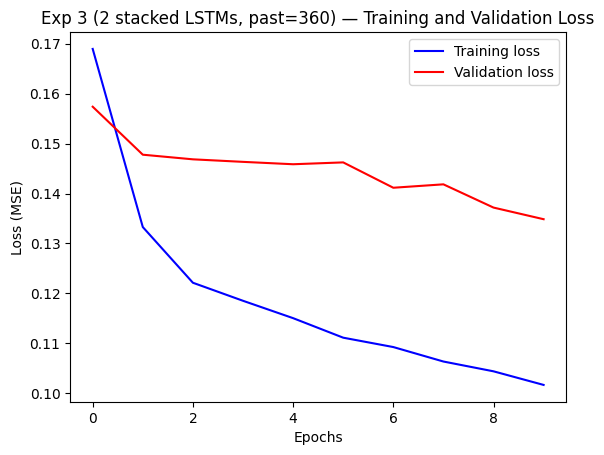

In [15]:
visualize_loss(history_exp3, "Exp 3 (2 stacked LSTMs, past=360) — Training and Validation Loss")


---
## Results Summary

| Experiment | LSTM Layers | LSTM Units | past | Best Val Loss (MSE) | vs Baseline |
|------------|-------------|------------|------|---------------------|-------------|
| Baseline   | 1           | 32         | 720  | 0.1317              | —           |
| Exp 1      | 1           | 64         | 720  | 0.1473              | +11.8%      |
| Exp 2      | 2           | 64         | 720  | 0.1321              | +0.3%       |
| Exp 3      | 2           | 64         | 360  | 0.1349              | +2.4%       |

**Full comparison of results shown in results.md**
